In [51]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import datasets
from sklearn.manifold import Isomap
from matplotlib import offsetbox
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [44]:
digits = datasets.load_digits()
data = digits.data
y = digits.target

In [45]:
def plot_embedding(X, title):
    _, ax = plt.subplots()
    X = MinMaxScaler().fit_transform(X)

    for digit in digits.target_names:
        ax.scatter(
            *X[y == digit].T,
            marker=f"${digit}$",
            s=60,
            color=plt.cm.Dark2(digit),
            alpha=0.425,
            zorder=2,
        )
    shown_images = np.array([[1.0, 1.0]])  # just something big
    for i in range(X.shape[0]):
        # plot every digit on the embedding
        # show an annotation box for a group of digits
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 4e-3:
            # don't show points that are too close
            continue
        shown_images = np.concatenate([shown_images, [X[i]]], axis=0)
        imagebox = offsetbox.AnnotationBbox(
            offsetbox.OffsetImage(digits.images[i], cmap=plt.cm.gray_r), X[i]
        )
        imagebox.set(zorder=1)
        ax.add_artist(imagebox)

    ax.set_title(title)
    ax.axis("off")

C:\Users\perri\anaconda3\envs\New_env_for_fun\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\perri\anaconda3\envs\New_env_for_fun\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


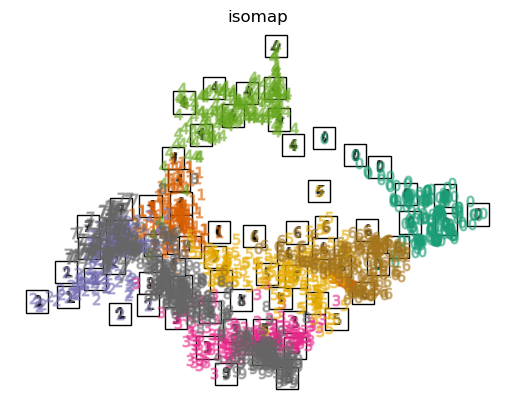

In [46]:
manif = Isomap() #reduce dimensionality from 64 to 2
reduced_digits = manif.fit_transform(data, targets)
plot_embedding(reduced_digits, 'isomap')

In [63]:
# classification of dataset
L = len(data[:, 0])
train_n = int(0.8*L)
test_n = int(L-train_n)

data_idxs = np.arange(0, L)
train_idx = np.random.choice(data_idxs, size=train_n)

train_data = []
test_data = []

for i in range(L):
    if i in train_idx:
        train_data.append(data[i, :])
    else:
        test_data.append(data[i, :])

In [68]:
train_data = np.array(train_data)
test_data = np.array(test_data)

